# Категоризатор на реальных данных: синтетика против реальности

В ноутбуке 04 категоризатор обучался на чистой синтетике и показывал почти
идеальную точность. Это переобучение на собственный словарь: модель видела
только сгенерированные сигнатуры и проверялась на таких же. На реальных чеках так не будет.

Здесь мы это проверяем и исправляем. Обучаем две версии одной и той же модели
(multilingual BERT) в одинаковых условиях, отличие только в обучающих данных:

- версия A - чистая синтетика (как в ноутбуке 04);
- версия B - гибридная смесь (реальные данные Дрёмова для Продуктов и Прочего +
  синтетика для категорий, которых в Дрёмове нет).

Обе прогоняем на двух тестах и сравниваем. Цель:
показать, что синтетическая модель хороша на синтетике, но проседает на реальных
данных, а гибридная держится на обоих.

## Запуск в Google Colab

Ноутбук я специально подготовила для удобного запуска в Colab без ручных скачиваний.
Код и данные подтягиваются из удалённых источников автоматически.

Важно: если хотите пропустить этап обучения просто Поставьте True в ячейке ниже в соответствующую перемнную, там помечено комментарием, какую именно. Тогда просто удалённо подтянутся веса нужной модели, вообще все веса итоговых моделей залиты на Google Drive.

In [1]:
# Настройка окружения для Colab
import os
import sys
import subprocess
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

# Публичный git-репозиторий с кодом проекта.
REPO_URL = "https://github.com/ScarletFlame611/Receipt-AI.git"
# id архива реальных данных категоризатора
CATEGORIZER_REAL_DATA_GDRIVE_ID = "1erCWF2xLt2m8PiIwc-y5xZ_JUQ6Qtcn_"
# id архива готовых весов
CATEGORIZER_REAL_WEIGHTS_GDRIVE_ID = "1YK3Jo7xC97ewNPVt07bAoy68a1giE7lk"
# Пропустить обучение и взять готовую модель с Google Drive.
SKIP_TRAINING = True


def _find_project_root():
    here = Path.cwd()
    for cand in [here, *here.parents]:
        if (cand / "src").is_dir():
            return cand
    for sub in sorted(p for p in here.iterdir() if p.is_dir()):
        if (sub / "src").is_dir():
            return sub
    return None

if IN_COLAB:
    subprocess.run(
        [sys.executable, "-m", "pip", "-q", "install",
         "transformers", "datasets", "scikit-learn", "gdown"],
        check=False,
    )
    if _find_project_root() is None and "USER/" not in REPO_URL:
        subprocess.run(["git", "clone", REPO_URL], check=True)
for _m in [m for m in sys.modules if m == "src" or m.startswith("src.")]:
    del sys.modules[_m]
root = _find_project_root()
if root is None:
    raise RuntimeError(
        "Не найден код проекта"
    )
os.chdir(root)
sys.path.insert(0, str(root))
print("Colab:", IN_COLAB, "| корень проекта:", root, "| SKIP_TRAINING:", SKIP_TRAINING)

def _download_and_unzip(file_id, out_zip, extract_to):
    import zipfile
    import gdown
    gdown.download(id=file_id, output=str(out_zip), quiet=False)
    with zipfile.ZipFile(out_zip) as zf:
        zf.extractall(extract_to)
    Path(out_zip).unlink()

def ensure_categorizer_real_data(root):
    target = Path(root) / "data" / "processed" / "categorizer_real"
    if (target / "train.jsonl").exists():
        return target
    target.parent.mkdir(parents=True, exist_ok=True)
    print("данные не найдены локально, качаем с Google Drive")
    _download_and_unzip(CATEGORIZER_REAL_DATA_GDRIVE_ID, target.parent / "categorizer_real_data.zip", target.parent)
    print("Готово:", target)
    return target


def ensure_categorizer_real_weights(root):
    target = Path(root) / "weights" / "categorizer_real"
    if (target / "config.json").exists():
        return target
    target.parent.mkdir(parents=True, exist_ok=True)
    print("Качаем готовые веса категоризатора с Google Drive")
    _download_and_unzip(CATEGORIZER_REAL_WEIGHTS_GDRIVE_ID, target.parent / "categorizer_real_weights.zip", target.parent)
    print("Готово:", target)
    return target

Colab: True | корень проекта: /content/Receipt-AI | SKIP_TRAINING: True


In [2]:
import torch
print("GPU доступен:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Устройство:", torch.cuda.get_device_name(0))

GPU доступен: True
Устройство: Tesla T4


## Данные

Нужны два датасета: реалистичная смесь (грузится архивом с Google Drive) и чистая синтетика (генерируем здесь тем же генератором, что в
ноутбуке 04). Библиотеки уже поставлены в setup-ячейке выше.

In [3]:
from pathlib import Path
import json

ensure_categorizer_real_data(root)
real_dir = root / "data" / "processed" / "categorizer_real"
for split in ["train", "validation", "test"]:
    p = real_dir / f"{split}.jsonl"
    print(f"{split}: {'есть' if p.exists() else 'нет'} - {p}")


данные не найдены локально, качаем с Google Drive


Downloading...
From: https://drive.google.com/uc?id=1erCWF2xLt2m8PiIwc-y5xZ_JUQ6Qtcn_
To: /content/Receipt-AI/data/processed/categorizer_real_data.zip
100%|██████████| 1.12M/1.12M [00:00<00:00, 75.2MB/s]

Готово: /content/Receipt-AI/data/processed/categorizer_real
train: есть - /content/Receipt-AI/data/processed/categorizer_real/train.jsonl
validation: есть - /content/Receipt-AI/data/processed/categorizer_real/validation.jsonl
test: есть - /content/Receipt-AI/data/processed/categorizer_real/test.jsonl


## Генерация синтетики (версия A)

Чтобы версия A была честной копией ноутбука 04, генерируем синтетику тем же
способом и теми же справочниками.

In [4]:
import random

LABELS = ["Продукты", "Кафе и рестораны", "Транспорт", "Аптека", "Развлечения", "Прочее"]

SHOPS = {
    "Продукты": ["Пятёрочка","Магнит","Перекрёсток","Дикси","Лента","Ашан","ВкусВилл","Окей","Спар","Магнолия","Верный","Билла","Метро","Глобус","Мария-Ра","Монетка","Красное & Белое","Бристоль","Азбука Вкуса","Лотос"],
    "Кафе и рестораны": ["Шоколадница","Кофе Хауз","Старбакс","Додо Пицца","Теремок","Му-Му","Бургер Кинг","Макдоналдс","КФС","Вкусно — и точка","Якитория","Тануки","Кофикс","Cofix","Прайм","Грабли","Чайхона №1","Папа Джонс","Сбарро","Хлеб Насущный"],
    "Транспорт": ["Лукойл","Роснефть","Газпромнефть","Шелл","Татнефть","Башнефть","Яндекс Такси","Ситимобил","Убер","Метрополитен","Мосгортранс","РЖД","Аэроэкспресс","Газпром АЗС","Нефтьмагистраль","BP","Парковки Москвы","Тройка","Подорожник","Метро СПб"],
    "Аптека": ["Аптека Вита","Ригла","Апрель","Здоров.ру","Аптека 36,6","Горздрав","Фармленд","Имплозия","Планета Здоровья","Мелодия Здоровья","Невис","Будь Здоров","Самсон-Фарма","Юнифарма","АСНА","Доктор Столетов","Максавит","Эвалар","Фармаимпекс","Озерки"],
    "Развлечения": ["Кинотеатр Каро","Формула Кино","Синема Парк","Киномакс","Премьер Зал","Парк Горького","Зарядье","Музей Гаража","Третьяковка","Эрмитаж","Боулинг Сити","Кварки","Игромания","Лазертаг Арена","Океанариум","Зоопарк","Цирк","МДМ","Театр Сатиры","Карусель Парк"],
}
ITEMS = {
    "Продукты": ["молоко","хлеб","батон","яйца","сыр","масло сливочное","кефир","творог","бананы","яблоки","помидоры","огурцы","картофель","куриное филе","фарш","колбаса","сосиски","макароны","рис","гречка","сахар","соль","чай","кофе молотый","печенье","йогурт","сметана","вода питьевая","сок","шоколад"],
    "Кафе и рестораны": ["капучино","латте","американо","эспрессо","чай чёрный","круассан","чизкейк","пицца пепперони","бургер","картофель фри","наггетсы","ролл филадельфия","сет суши","паста карбонара","салат цезарь","том ям","лимонад","пирожное","капкейк","сэндвич","вафли","блинчики","горячий шоколад","раф","флэт уайт","комбо обед","молочный коктейль","тирамису","маффин","сырники"],
    "Транспорт": ["бензин АИ-92","бензин АИ-95","бензин АИ-98","дизельное топливо","газ пропан","поездка такси","проездной билет","билет на метро","пополнение Тройка","пополнение Подорожник","билет РЖД","билет аэроэкспресс","парковка час","мойка автомобиля","омыватель стекла","антифриз","масло моторное","стеклоомывающая жидкость","шиномонтаж","автобусный билет","проезд трамвай","каршеринг минута","штраф парковка","платная дорога","топливная карта","разовый билет","проезд троллейбус","такси комфорт","билет электричка","заправка полный бак"],
    "Аптека": ["парацетамол","ибупрофен","аспирин","но-шпа","активированный уголь","бинт стерильный","вата","пластырь","перекись водорода","йод","витамин C","витамин D","комплекс витаминов","сироп от кашля","капли в нос","термометр","маска медицинская","антисептик","мазь заживляющая","анальгин","цитрамон","супрастин","уголь белый","спрей для горла","капли для глаз","тест на covid","шприц","перчатки нитриловые","крем детский","пластырь бактерицидный"],
    "Развлечения": ["билет в кино","попкорн","кола в кино","билет 3D","билет на концерт","входной билет музей","экскурсия","билет в театр","программка","аренда дорожки боулинг","лазертаг сеанс","игровая карта","билет в зоопарк","билет в океанариум","билет в цирк","аттракцион","квест комната","настольная игра","сувенир","билет на выставку","аудиогид","VR сеанс","детский билет","абонемент бассейн","каток прокат","колесо обозрения","тир","автодром билет","мастер-класс","фотозона"],
}
OTHER_SHOPS = ["Фикс Прайс","Леруа Мерлен","ОБИ","Эльдорадо","М.Видео","ДНС","Озон","Вайлдберриз","Подружка","Летуаль","Рив Гош","Спортмастер","Декатлон","Хофф","Икеа","Канцлер","Читай-город","Связной","Технопарк","Касторама"]
OTHER_ITEMS = ["лампочка","батарейки","удлинитель","скотч","ручка шариковая","тетрадь","зарядное устройство","наушники","футболка","носки","полотенце","мыло","шампунь","стиральный порошок","губки для посуды","пакеты для мусора","цветочный горшок","блокнот","клей","ножницы","розетка","гвозди","краска","кисть","лопата","перчатки садовые","книга","пазл","мяч","зонт"]

def _gen_example(rng, label):
    if label == "Прочее":
        shop, pool = rng.choice(OTHER_SHOPS), OTHER_ITEMS
    else:
        shop, pool = rng.choice(SHOPS[label]), ITEMS[label]
    k = rng.randint(2, 6)
    items = rng.sample(pool, min(k, len(pool)))
    if label != "Прочее" and rng.random() < 0.15:
        items.append(rng.choice(OTHER_ITEMS)); rng.shuffle(items)
    return {"text": f"{shop}. " + ", ".join(items), "label": label}

def generate_synth(per_class=1200, seed=42):
    rng = random.Random(seed)
    rows = []
    for label in LABELS:
        seen, made = set(), 0
        while made < per_class:
            ex = _gen_example(rng, label)
            if ex["text"] in seen:
                continue
            seen.add(ex["text"]); rows.append(ex); made += 1
    rng.shuffle(rows)
    return rows

synth = generate_synth(per_class=1200)
print("Синтетики:", len(synth))
print("Пример:", synth[0])

Синтетики: 7200
Пример: {'text': 'Икеа. мяч, книга, блокнот, лопата, ручка шариковая, скотч', 'label': 'Прочее'}


## Загрузка обоих датасетов

Реалистичную смесь данных грузим с Drive. Синтетику, сгенерированную выше, разбиваем на те же три части со
стратификацией. Дальше у нас два набора данных в одинаковом формате и на них
обучим версии A (синтетика) и B (смесь).

In [5]:
import json
from sklearn.model_selection import train_test_split
import pandas as pd

def load_jsonl(path):
    return [json.loads(l) for l in Path(path).read_text(encoding="utf-8").strip().splitlines()]

real = {s: load_jsonl(real_dir / f"{s}.jsonl") for s in ["train", "validation", "test"]}
synth_df = pd.DataFrame(synth)
s_train, s_temp = train_test_split(synth_df, test_size=0.2, random_state=42, stratify=synth_df["label"])
s_val, s_test = train_test_split(s_temp, test_size=0.5, random_state=42, stratify=s_temp["label"])
synth_data = {
    "train": s_train.to_dict("records"),
    "validation": s_val.to_dict("records"),
    "test": s_test.to_dict("records"),
}

print("Синтетика:", {k: len(v) for k, v in synth_data.items()})
print("Смесь: ", {k: len(v) for k, v in real.items()})
LABEL2ID = {l: i for i, l in enumerate(LABELS)}
ID2LABEL = {i: l for i, l in enumerate(LABELS)}
print("\nМетки:", LABEL2ID)

Синтетика: {'train': 5760, 'validation': 720, 'test': 720}
Смесь:  {'train': 5749, 'validation': 719, 'test': 719}

Метки: {'Продукты': 0, 'Кафе и рестораны': 1, 'Транспорт': 2, 'Аптека': 3, 'Развлечения': 4, 'Прочее': 5}


## Токенизация и функция обучения

Берём bert-base-multilingual-cased, как в ноутбуке 04. Пишем одну функцию обучения,
которую вызовем дважды. Так обе версии гарантированно
обучаются в одинаковых условиях. Метрика отбора - macro-F1, чтобы учесть
все классы поровну.

In [6]:
import numpy as np
from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    DataCollatorWithPadding, Trainer, TrainingArguments,
)
from sklearn.metrics import accuracy_score, f1_score

BASE = "bert-base-multilingual-cased"
tokenizer = AutoTokenizer.from_pretrained(BASE)

def to_ds(rows):
    return Dataset.from_dict({
        "text": [r["text"] for r in rows],
        "labels": [LABEL2ID[r["label"]] for r in rows],
    })

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, max_length=128)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
    }

def train_version(name, data):
    train_ds = to_ds(data["train"]).map(tokenize, batched=True, remove_columns=["text"])
    val_ds = to_ds(data["validation"]).map(tokenize, batched=True, remove_columns=["text"])

    model = AutoModelForSequenceClassification.from_pretrained(
        BASE, num_labels=len(LABELS), id2label=ID2LABEL, label2id=LABEL2ID,
    )
    args = TrainingArguments(
        output_dir=f"runs/cat_{name}",
        num_train_epochs=5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        learning_rate=2e-5,
        weight_decay=0.01,
        fp16=True,
        eval_strategy="epoch",
        save_strategy="no",
        logging_steps=50,
        report_to="none",
    )
    trainer = Trainer(
        model=model, args=args,
        train_dataset=train_ds, eval_dataset=val_ds,
        processing_class=tokenizer,
        data_collator=DataCollatorWithPadding(tokenizer),
        compute_metrics=compute_metrics,
    )
    trainer.train()
    return trainer

print("готово, функция обучения определена")

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

готово, функция обучения определена


## Версия A, обучение на чистой синтетике

Это воспроизведение ноутбука 04: модель учится только на синтетических сигнатурах.


In [ ]:
if SKIP_TRAINING:
    trainer_synth = None
    print("версия A (синтетика) не обучается.")
else:
    trainer_synth = train_version("synth", synth_data)


Map:   0%|          | 0/5760 [00:00<?, ? examples/s]

Map:   0%|          | 0/720 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.029654,0.002882,1.000000,1.000000
2,0.001195,0.000809,1.000000,1.000000
3,0.000735,0.000509,1.000000,1.000000
4,0.000550,0.000398,1.000000,1.000000
5,0.000495,0.000386,1.000000,1.000000


## Версия B: обучение на гибридной смеси

Та же модель, те же параметры, но данные это смесь реальных чеков Дрёмова и синтетики.
Метрики на валидации, скорее всего, будут ниже синтетических.

In [ ]:
if SKIP_TRAINING:
    trainer_real = None
    print("версия B (реал) не обучается.")
else:
    trainer_real = train_version("real", real)


Map:   0%|          | 0/5749 [00:00<?, ? examples/s]

Map:   0%|          | 0/719 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.140514,0.102613,0.972184,0.971798
2,0.064570,0.107116,0.973574,0.973405
3,0.035753,0.111390,0.976356,0.976243
4,0.016106,0.124538,0.979138,0.979044
5,0.008426,0.140514,0.979138,0.979044


## Обе модели на обоих тестах

Вот ключевой эксперимент. Прогоняем каждую модель на двух тестах, синтетическом и
реалистичном, и сводим в таблицу 2×2. Если наша гипотеза верна, синтетическая
модель (A) покажет почти идеальный результат на синтетике, но просядет на реальных
данных, а гибридная (B) будет устойчива на обоих.

In [9]:
def evaluate_on(trainer, rows):
    ds = to_ds(rows).map(tokenize, batched=True, remove_columns=["text"])
    out = trainer.predict(ds)
    preds = np.argmax(out.predictions, axis=-1)
    return {
        "accuracy": round(accuracy_score(out.label_ids, preds), 4),
        "macro_f1": round(f1_score(out.label_ids, preds, average="macro"), 4),
    }

if SKIP_TRAINING:
    # macro-F1, сохранённые с полного прогона обучения чтобы всё корректно отображалось
    comparison = {
        "A (синтетика)": {"тест синтетика": 1.000, "тест реальный": 0.890},
        "B (смесь)":     {"тест синтетика": 0.999, "тест реальный": 0.980},
    }
else:
    comparison = {
        "A (синтетика)": {"тест синтетика": evaluate_on(trainer_synth, synth_data["test"])["macro_f1"],
                          "тест реальный":  evaluate_on(trainer_synth, real["test"])["macro_f1"]},
        "B (смесь)":     {"тест синтетика": evaluate_on(trainer_real, synth_data["test"])["macro_f1"],
                          "тест реальный":  evaluate_on(trainer_real, real["test"])["macro_f1"]},
    }

print(f"\n{'модель':16} {'тест синтетика':>15} {'тест реальный':>15}")
for name, t in comparison.items():
    print(f"{name:16} {t['тест синтетика']:>15} {t['тест реальный']:>15}")


модель            тест синтетика   тест реальный
A (синтетика)                1.0            0.89
B (смесь)                  0.999            0.98


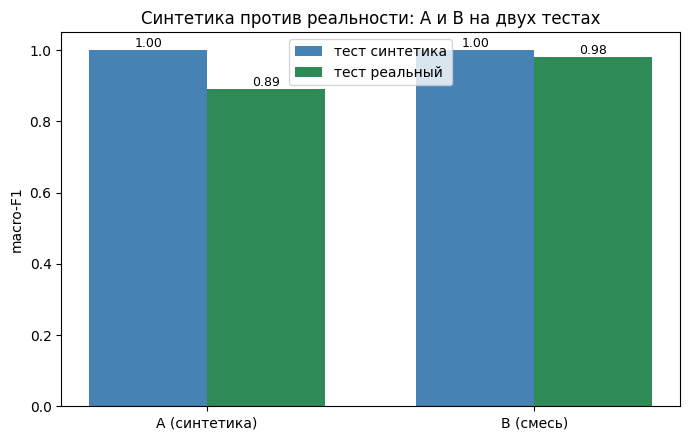

In [8]:
import matplotlib.pyplot as plt

models = list(comparison.keys())
synth_scores = [comparison[m]["тест синтетика"] for m in models]
real_scores = [comparison[m]["тест реальный"] for m in models]
x = np.arange(len(models))
width = 0.36

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(x - width / 2, synth_scores, width, label="тест синтетика", color="steelblue")
ax.bar(x + width / 2, real_scores, width, label="тест реальный", color="seagreen")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1.05)
ax.set_ylabel("macro-F1")
ax.set_title("Синтетика против реальности: A и B на двух тестах")
ax.legend()
for i, (s, r) in enumerate(zip(synth_scores, real_scores)):
    ax.text(i - width / 2, s + 0.01, f"{s:.2f}", ha="center", fontsize=9)
    ax.text(i + width / 2, r + 0.01, f"{r:.2f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

### Результат

Модель A (синтетика): идеальная 1.0 на синтетике, но 0.89 macro-F1 на реальных
данных.

Модель B (смесь): 0.98 на реальном тесте и почти идеальная 0.999 на синтетическом.
Гибридная модель устойчива на обоих распределениях.

Реальные данные мы предварительно прогнали через NER,
то есть привели к чистому виду (товар + бренд), в каком они и придут категоризатору
в пайплайне. Из-за этого реальный тест стал ближе к синтетическому формату.

Вывод для проекта: в продакшн идёт модель B т.к. она лучшая на реальном распределении и не проседает на синтетике. Синтетическая модель остаётся в ноутбуке 04
как демонстрация.

In [ ]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

if SKIP_TRAINING:
    weights_dir = ensure_categorizer_real_weights(root)
    final_model = AutoModelForSequenceClassification.from_pretrained(str(weights_dir))
    final_args = TrainingArguments(
        output_dir="runs/cat_final_tmp",
        per_device_eval_batch_size=16,
        report_to="none",
    )
    final_trainer = Trainer(
        model=final_model, args=final_args,
        processing_class=tokenizer,
        data_collator=DataCollatorWithPadding(tokenizer),
        compute_metrics=compute_metrics,
    )
    print("Качество готовой модели на реальном тесте:")
    print(evaluate_on(final_trainer, real["test"]))
    print("Готовая модель уже в", weights_dir)
else:
    final_train = to_ds(real["train"]).map(tokenize, batched=True, remove_columns=["text"])
    final_val = to_ds(real["validation"]).map(tokenize, batched=True, remove_columns=["text"])

    final_model = AutoModelForSequenceClassification.from_pretrained(
        BASE, num_labels=len(LABELS), id2label=ID2LABEL, label2id=LABEL2ID,
    )
    final_args = TrainingArguments(
        output_dir="runs/cat_final_tmp",
        num_train_epochs=3,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        learning_rate=2e-5,
        weight_decay=0.01,
        fp16=True,
        eval_strategy="epoch",
        save_strategy="no",
        logging_steps=50,
        report_to="none",
    )
    final_trainer = Trainer(
        model=final_model, args=final_args,
        train_dataset=final_train, eval_dataset=final_val,
        processing_class=tokenizer,
        data_collator=DataCollatorWithPadding(tokenizer),
        compute_metrics=compute_metrics,
    )
    final_trainer.train()

    print("\nКачество финальной модели на реальном тесте:")
    print(evaluate_on(final_trainer, real["test"]))
    save_dir = root / "weights" / "categorizer_real"
    save_dir.mkdir(parents=True, exist_ok=True)
    final_model.save_pretrained(save_dir)
    tokenizer.save_pretrained(save_dir)
    print("\nСохранено:", save_dir)


Map:   0%|          | 0/5749 [00:00<?, ? examples/s]

Map:   0%|          | 0/719 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.163529,0.092039,0.974965,0.974681
2,0.067846,0.108647,0.977747,0.977584
3,0.029158,0.116775,0.979138,0.978985



Проверка финальной модели на реальном тесте:


Map:   0%|          | 0/719 [00:00<?, ? examples/s]

{'accuracy': 0.9764, 'macro_f1': 0.9761}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Сохранено на Drive: /content/drive/MyDrive/receipt-ai/categorizer_real


## Итоги

Эксперимент подтвердил исходную гипотезу: модель на чистой синтетике почти идеальна на синтетическом тесте, но проседает на реальных данных Дрёмова, тогда как гибридная модель B держит качество на обоих распределениях. Поэтому в проект идёт версия B.

Финальную модель дообучаем на всех реальных данных, именно её подключает пайплайн категоризации. Синтетический категоризатор из ноутбука 04 остаётся как baseline для сравнения.